In [1]:
from hydra import initialize, compose
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.patches import Patch
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

def find_between_rules(s):
    match = re.search(r'_rules_(.+?)_rules_', s)
    return match.group(1) if match else None

In [2]:
cutoff_date = 2015
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub = pub.explode("publication_dates")
pub = pub.group_by("id").agg(pl.col("publication_dates").min()).filter(pl.col("publication_dates") >= cutoff_date).rename({"publication_dates": "pub_date"})
tot_pub_rxns = pub.shape[0]
print(f"Total reactions with publication date >= {cutoff_date}: {tot_pub_rxns:,}")
pub.head()

Total reactions with publication date >= 2015: 4,466


id,pub_date
str,i32
"""9040f2a89f9e1dfd2b689d43c128c9…",2024
"""23fb95f5d9ff446497165597810bd6…",2016
"""b98de357572db43d88f76760d1068f…",2015
"""a89ba42724de8172b6c208db26eaa3…",2020
"""0695a170a17d43772cf9723fea36c1…",2024


In [3]:
metrics = []
for fn in (Path(cfg.interim_data) / "std_pickaxe_rxns").glob("*.parquet"):
    _name = find_between_rules(fn.stem)

    maps = pl.read_parquet(
        Path(cfg.raw_data) / "mappings" / f"mapped_known_reactions_x_{_name}_rules_before_{cutoff_date}.parquet"
    )

    pred = pl.read_parquet(fn)
    _n_pub_recovered = maps.join(pub, left_on="rxn_id", right_on="id", how="inner").shape[0]
    metrics.append(
        {
            "name": _name,
            "num_rxns": len(pred),
            "num_unique_rxns": pred["std_rxn"].n_unique(),
            "num_pub_rxns": _n_pub_recovered,
            "frac_pub_rxns": _n_pub_recovered / tot_pub_rxns,
            "fn": fn,
        }
    )

metrics.append(
    {
        "name": "rc_plus_0",
        "num_rxns": 7666721,
        "num_unique_rxns": 7666721,
        "num_pub_rxns": 2690,
        "frac_pub_rxns": 2690 / tot_pub_rxns,
         "fn": None,
    }
)

metrics = pl.DataFrame(metrics)
metrics.head(13)

name,num_rxns,num_unique_rxns,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""rc_plus_2""",73707,73702,1612,0.360949,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_2_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rc_plus_1""",132439,131469,2048,0.458576,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_1_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rc_plus_3""",57791,57789,1208,0.270488,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_3_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_005""",58699,58682,1331,0.29803,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_005_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_932""",726073,723410,2519,0.564039,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet
…,…,…,…,…,…
"""mechinferred_dt_021""",81059,81052,1902,0.425884,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_021_rules_before_2015_w_coreactants_aplusb_True.parquet
"""mechinferred_dt_009""",67849,67833,1609,0.360278,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_009_rules_before_2015_w_coreactants_aplusb_True.parquet
"""rc_plus_4""",52506,52467,1046,0.234214,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_rc_plus_4_rules_before_2015_w_coreactants_aplusb_True.parquet


In [4]:
Rs = [0, 1, 2, 3, 4]
dts = ['932', '069', '021', '009', '005']
others = ['mechinformed', 'rdchiral', 'imt']
mechinferred_template_sizes = defaultdict(list)
rcr_template_sizes = defaultdict(list)
bad_rules = {'rcr': set(), 'mechinferred': set()}
mechinferred_rules = []
rcr_rules = []
other_rules = []
other_template_sizes = defaultdict(list)

for dt in dts:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}.csv",
    )
    mechinferred_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        mechinferred_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for R in Rs:
    if R == 0:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_0_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_{R}_rules_before_{cutoff_date}.csv",
        )
    rcr_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        rcr_template_sizes[R].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for other in others:
    if other == 'imt':
        df = pl.read_csv(
            Path(cfg.rules) / f"imt_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"{other}_rules_before_{cutoff_date}.csv",
        )
    other_rules.append(df)
    for row in df.iter_rows(named=True):
            sma = row["smarts"]
            rxn = AllChem.ReactionFromSmarts(sma)
            other_template_sizes[other].append(
                sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
            )

median_template_size = {}

for name in metrics["name"].unique().to_list():
    vals = None

    if name.startswith("mechinferred_dt_"):
        dt = name.split("_")[-1]
        vals = mechinferred_template_sizes.get(dt, [])
    elif name.startswith("rc_plus_"):
        R = int(name.split("_")[-1])
        vals = rcr_template_sizes.get(R, [])
    else:
        vals = other_template_sizes.get(name, [])

    median_template_size[name] = pl.Series(vals).median() if vals else None

median_template_size


{'mechinferred_dt_932': 4.0,
 'rc_plus_1': 8.0,
 'mechinformed': 7.0,
 'rdchiral': 10.0,
 'mechinferred_dt_021': 30.0,
 'rc_plus_4': 21.0,
 'mechinferred_dt_069': 18.0,
 'mechinferred_dt_009': 34.0,
 'rc_plus_0': 5.0,
 'rc_plus_2': 13.0,
 'imt': 3.0,
 'rc_plus_3': 17.0,
 'mechinferred_dt_005': 40.0}

In [5]:
# Plot cfg

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

exp_labels = {
    'mechinformed': "Distilled",
    'mechinferred_dt_932': "Learned >0.932",
    'mechinferred_dt_069': "Learned >0.069",
    'mechinferred_dt_021': "Learned >0.021",
    'mechinferred_dt_009': "Learned >0.009",
    'mechinferred_dt_005': "Learned >0.005",
    'rc_plus_0': "RC + 0",
    'rc_plus_1': "RC + 1",
    'rc_plus_2': "RC + 2",
    'rc_plus_3': "RC + 3",
    'rc_plus_4': "RC + 4",
    'imt': "Pathway-level clustering",
    'rdchiral': "RDChiral",
}

colors = {
    'mechinformed': matplotlib.colors.to_rgba("green"),
    'mechinferred_dt_932': matplotlib.colors.to_rgba("purple", alpha=0.3),
    'mechinferred_dt_069': matplotlib.colors.to_rgba("purple", alpha=0.45),
    'mechinferred_dt_021': matplotlib.colors.to_rgba("purple", alpha=0.6),
    'mechinferred_dt_009': matplotlib.colors.to_rgba("purple", alpha=0.85),
    'mechinferred_dt_005': matplotlib.colors.to_rgba("purple", alpha=1.0),
    'rc_plus_0': matplotlib.colors.to_rgba("black", alpha=0.3),
    'rc_plus_1': matplotlib.colors.to_rgba("black", alpha=0.45),
    'rc_plus_2': matplotlib.colors.to_rgba("black", alpha=0.6),
    'rc_plus_3': matplotlib.colors.to_rgba("black", alpha=0.85),
    'rc_plus_4': matplotlib.colors.to_rgba("black", alpha=1.0),
    'imt': matplotlib.colors.to_rgba("darkorange"),
    'rdchiral': matplotlib.colors.to_rgba("blue"),
}

exp_names = list(exp_labels.keys())

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

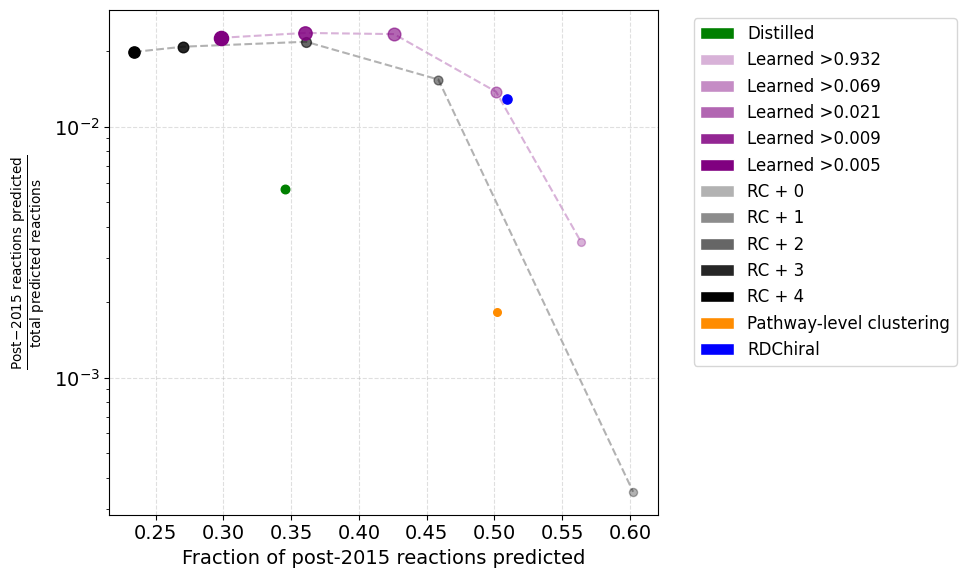

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()


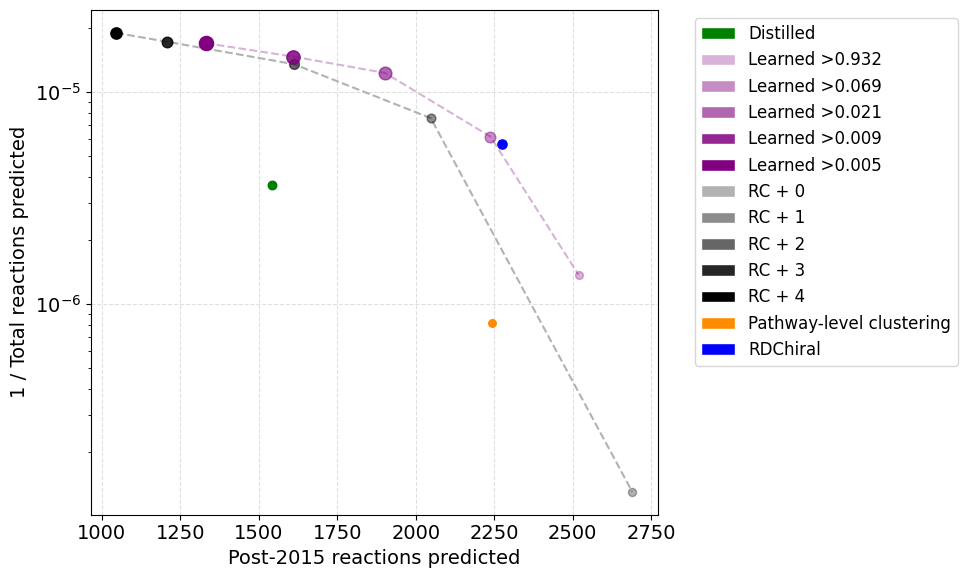

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

# Separate data by group
mechinferred_data = []
rcr_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if name not in exp_labels:
        continue
    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    point_data = {
        "name": name,
        "x": row["num_pub_rxns"],
        "y": 1 / row["num_rxns"],
        "color": colors[name],
        "marker_size": marker_size,
    }

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append(point_data)
    elif name.startswith("rc_plus_"):
        rcr_data.append(point_data)

# Plot mechinferred points and connect with dashed line
if mechinferred_data:
    mechinferred_data.sort(key=lambda p: p["x"])
    ax.plot(
        [p["x"] for p in mechinferred_data],
        [p["y"] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# Plot rcr points and connect with dashed line
if rcr_data:
    rcr_data.sort(key=lambda p: p["x"])
    ax.plot(
        [p["x"] for p in rcr_data],
        [p["y"] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# Plot all points
for row in metrics.iter_rows(named=True):
    name = row["name"]
    if name not in exp_labels:
        continue
    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    ax.scatter(
        row["num_pub_rxns"],
        1 / row["num_rxns"],
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

ax.set_xlabel(f"Post-{cutoff_date} reactions predicted")
ax.set_ylabel("1 / Total reactions predicted")
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()
